# Attention Policy for Time-Constrained Route Planning

## The agent selects POIs sequentially on a real OSM walking graph and returns home, trying to match a target duration. 


### Libraries

In [2]:
import os
import json
import time
import pickle
import warnings
import contextlib
from dataclasses import dataclass, field
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from scipy.spatial import ConvexHull
from tqdm import tqdm

import torch
import torch.nn as nn
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from stable_baselines3.common.type_aliases import Schedule
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.maskable.distributions import MaskableDistribution

from IPython.display import Image, display

warnings.filterwarnings("ignore")


### Configuration and parameters setup

In [ ]:
@dataclass(frozen=True)
class EnvConfig:
    num_pois: int = 80                  # number of POIs extracted by the map
    radius_meters: int = 3000           # 3 km radius of map
    masking_mode: str = "no_emergency"   # 'ontological' | 'full' | 'no_emergency' | 'disabled'
    use_circularity_bonus: bool = True  # whether to include the circularity bonus in the reward

    walking_speed_kmh: float = 5.0

    max_steps: int = 60                 # maximum number of steps per episode (after which it terminates with zero reward)
    max_target_duration: float = 120.0
    max_coord_diff: float = 0.03        # ~3.3 km at 50°N (lat_diff of 0.03 corresponds to ~3.3 km)

    # Reward weights (see reward shaping section in the report for details)
    w_new_node: float = 0.30
    w_revisit_node: float = -0.30
    w_duplicate_edge: float = -0.10
    step_shaping_cap: float = -3.0
    w_temporal_dense: float = 0.10
    w_terminal_time_max: float = 100.0
    w_terminal_time_cap: float = -30.0
    w_circularity_max: float = 25.0
    circularity_error_gate: float = 0.50

    # Curriculum target range for the episode duration (in minutes) 
    initial_min_target: float = 60.0
    initial_max_target: float = 120.0
    final_min_target: float = 10.0
    final_max_target: float = 120.0


@dataclass(frozen=True)
class PolicyConfig:                    # Encoder policy architecture hyperparameters
    d_model: int = 128
    n_heads: int = 8
    dropout: float = 0.0
    logit_clip_C: float = 10.0          # clip for the action logits (to stabilize training)

    n_critic_layers: int = 2            # layers of the network
    critic_hidden: int = 256            # hidden units per layer

    context_dim: int = 13               # 5 scalars + 2 home_vec + 6 target_vec
    poi_feature_dim: int = 5            # visited, dx, dy, t_norm, feasibility


@dataclass(frozen=True)
class TrainConfig:                      # Training hyperparameters
    learning_rate: float = 3e-4
    n_steps: int = 2048
    batch_size: int = 512
    n_epochs: int = 5
    gamma: float = 0.99
    gae_lambda: float = 0.95
    ent_coef: float = 0.01
    clip_range: float = 0.2
    vf_coef: float = 0.5            

    n_envs: int = 16                           # number of parallel environments for training
    total_timesteps: int = 5_000_000           # total timesteps of training 
    curriculum_phase2_start: int = 500_000     # [30, 120] minutes of episode duration
    curriculum_phase3_start: int = 1_500_000   # [10, 120] minutes of episode duration

    model_save_path: str = "ppo_walking"

    training_cities: tuple[str, ...] = (        # multicity training for better generalization (see report for details)
        "Brussels, Belgium",
        "Barcelona, Spain",
        "Vienna, Austria",
        "Lisbon, Portugal",
        "Amsterdam, Netherlands",
    )
    eval_cities: tuple[str, ...] = (            # multicity evaluation on unseen cities
        "Florence, Italy",
        "Prague, Czech Republic",
    )


@dataclass(frozen=True)                         # Main config dataclass that aggregates all other configs for easy access
class Config:
    env: EnvConfig = field(default_factory=EnvConfig)
    policy: PolicyConfig = field(default_factory=PolicyConfig)
    train: TrainConfig = field(default_factory=TrainConfig)


CONFIG = Config()


### Graph Utilities

Download (or load from cache) the pedestrian graph  
Pick a random home node and "num_pois" POIs spread by network distance (picked by a distribution closer to home node)  
Precompute shortest paths between the key nodes only having distance and times.

In [4]:
def get_or_create_graph(place, num_pois=80, radius_meters=3000, cache_dir="cache"):  # Download the graph for the city from OSM, extract POIs and precompute shortest paths between them, with caching to speed up subsequent runs
    os.makedirs(cache_dir, exist_ok=True)
    slug = "".join(c if c.isalnum() else "_" for c in place.lower())
    graph_path = os.path.join(cache_dir, f"graph_{slug}_{radius_meters}m.graphml")
    info_path = os.path.join(cache_dir, f"graph_info_{slug}_{radius_meters}m_precomputed.pkl")

    if os.path.exists(graph_path) and os.path.exists(info_path):  # load from cache if available
        print(f"Loading cached graph for {place} …")
        G = ox.load_graphml(graph_path)
        with open(info_path, "rb") as f:
            home_node, pois, paths, path_lengths = pickle.load(f)
        return G, home_node, pois, paths, path_lengths

    print(f"Downloading graph for {place} ({radius_meters} m) …")
    G = ox.graph_from_point(ox.geocode(place), dist=radius_meters, network_type="walk")  # get the walking graph for the city within the specified radius
    G = max((G.subgraph(c) for c in nx.strongly_connected_components(G)), key=len)       # keep only the largest strongly connected component to ensure all nodes are reachable from each other

    nodes = list(G.nodes)   
    np.random.seed(42)                       # fixed home + POIs per city
    home_node = np.random.choice(nodes)      # randomly select a home node from the graph

    # POIs spread by distance: split nodes (sorted by distance from home) into
    # num_pois buckets and pick one random node per bucket.
    distances = nx.single_source_dijkstra_path_length(G, home_node, weight="length")  # compute shortest path distances from home to all other nodes in a efficient way
    sorted_nodes = sorted(distances, key=distances.get)
    chunk = max(1, len(sorted_nodes) // num_pois)
    pois = []
    for i in range(num_pois):
        bucket = sorted_nodes[i * chunk: (i + 1) * chunk]
        if home_node in bucket:
            bucket.remove(home_node)
        pois.append(np.random.choice(bucket) if bucket else np.random.choice(nodes))
    np.random.shuffle(pois)
    pois = list(pois)

    # Shortest paths between key nodes only (home + POIs): single-source Dijkstra.
    key_nodes = [home_node] + pois
    paths, path_lengths = {}, {}
    for u in tqdm(key_nodes, desc=f"Routing {place}"):
        lengths, all_paths = nx.single_source_dijkstra(G, u, weight="length")
        paths[u] = {v: all_paths.get(v, []) for v in key_nodes}
        path_lengths[u] = {v: lengths.get(v, float("inf")) for v in key_nodes}

    ox.save_graphml(G, graph_path)
    with open(info_path, "wb") as f:
        pickle.dump((home_node, pois, paths, path_lengths), f)
    return G, home_node, pois, paths, path_lengths

### Environment

#### WalkingEnv is a Gymnasium environment. 
Observation: 5 scalars + home vector + target_vectors + per-POI features  
Action: pick a POI or go home (terminate)  
Reward: it combines time precision, circularity and dense temporal shaping.

In [5]:
class WalkingEnv(gym.Env):                 # Custom OpenAI Gym environment for the walking loop task, with state representation, action masking and reward shaping as described in the report
    metadata = {"render_modes": ["human"]}

    def __init__(self, places, cfg=None):
        super().__init__()
        self.cfg = cfg or EnvConfig()
        self.places = [places] if isinstance(places, str) else list(places)

        # saving the config to the instance for easy access in methods, and extracting relevant parameters for convenience
        c = self.cfg 
        self.WALKING_SPEED_M_MIN = c.walking_speed_kmh * 1000.0 / 60.0
        self.MAX_TARGET_DURATION = c.max_target_duration
        self.MAX_COORD_DIFF = c.max_coord_diff
        self.max_steps = c.max_steps
        self.num_pois = c.num_pois

        self._min_target = c.initial_min_target
        self._max_target = c.initial_max_target

        self.city_data = {}
        for place in self.places:               # precompute and store the graph, POIs and shortest paths for each city in the config
            G, home, pois, paths, path_lengths = get_or_create_graph(
                place, c.num_pois, c.radius_meters
            )
            self.city_data[place] = {
                "G": G, "home_node": home, "pois": pois,
                "paths": paths, "path_lengths": path_lengths,
            }
        self._set_active_city(self.places[0])   # initialize the environment with the first city (will be overridden in reset)

        self.action_space = spaces.Discrete(self.num_pois + 1)
        obs_dim = 5 + 2 + 6 + self.num_pois * 5
        self.observation_space = spaces.Box(-np.inf, np.inf, (obs_dim,), np.float32)

        self.city_error_ewma = {p: 1.0 for p in self.places}

    def set_target_range(self, min_t, max_t):
        self._min_target = float(min_t)
        self._max_target = float(max_t)

    def _set_active_city(self, place):        # Set the active city for the environment (load the corresponding graph, POIs and paths into memory)
        self.current_city_name = place
        data = self.city_data[place]
        self.G = data["G"]
        self.home_node = data["home_node"]
        self.base_pois = data["pois"]
        self.paths = data["paths"]
        self.path_lengths = data["path_lengths"]

        key_nodes = [self.home_node] + list(self.base_pois)
        n = len(key_nodes)
        self._kn_to_idx = {node: i for i, node in enumerate(key_nodes)}
        self._home_idx = 0

        self._dist_matrix = np.full((n, n), np.inf, dtype=np.float32)
        for i, u in enumerate(key_nodes):
            pl_u = self.path_lengths.get(u, {})
            for j, v in enumerate(key_nodes):
                if v in pl_u:
                    self._dist_matrix[i, j] = float(pl_u[v])
        self._dist_matrix[np.arange(n), np.arange(n)] = 0.0

        self._home_coords = np.array(
            [self.G.nodes[self.home_node]["x"], self.G.nodes[self.home_node]["y"]],
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):    # Reset the environment to start a new episode
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)

        # City: explicit override (used by eval/test) and prioritised EWMA sampling.
        if options and "city" in options:
            city = options["city"]
        else: # if no explicit city is provided in options, sample based on EWMA
            weights = np.array([self.city_error_ewma[p] for p in self.places], dtype=np.float64)
            weights /= weights.sum()
            city = np.random.choice(self.places, p=weights)
        self._set_active_city(city)

        if options and "target_duration" in options:
            self.target_duration = float(options["target_duration"])
        else:
            self.target_duration = float(np.random.uniform(self._min_target, self._max_target))

        self.episode_pois = list(self.base_pois)
        np.random.shuffle(self.episode_pois)
        self._ep_poi_indices = np.array(
            [self._kn_to_idx[p] for p in self.episode_pois], dtype=np.int32
        )
        self._ep_poi_coords = np.array(
            [[self.G.nodes[p]["x"], self.G.nodes[p]["y"]] for p in self.episode_pois],
            dtype=np.float32,
        )
        self._ep_poi_home_dist = self._dist_matrix[self._ep_poi_indices, self._home_idx]

        self.current_duration = 0.0             # default values for the start of the episode
        self.current_node = self.home_node
        self._current_idx = self._home_idx
        self.visited_nodes = {self.home_node}
        self.visited_edges = set()
        self._visited_mask_np = np.zeros(self.num_pois, dtype=np.float32)
        self.visited_pois_mask = [0] * self.num_pois
        self.episode_path = [self.home_node]
        self.step_count = 0
        self.breadcrumbs = [self.home_node, self.home_node, self.home_node]

        return self._get_obs(), {}

    def _get_obs(self):       # Construct the observation vector for the current state
        curr_x = float(self.G.nodes[self.current_node]["x"])   # current node coordinates for geometric context and relative position encoding
        curr_y = float(self.G.nodes[self.current_node]["y"])
        curr_xy = np.array([curr_x, curr_y], dtype=np.float32)

        target_norm = self.target_duration / self.MAX_TARGET_DURATION
        current_norm = self.current_duration / self.MAX_TARGET_DURATION

        dist_to_home = float(self._dist_matrix[self._current_idx, self._home_idx])
        time_to_home = dist_to_home / self.WALKING_SPEED_M_MIN
        time_to_home_norm = time_to_home / self.MAX_TARGET_DURATION

        delta_real = self.target_duration - self.current_duration
        delta_norm = float(np.clip(delta_real / self.MAX_TARGET_DURATION, -1.0, 1.0))
        urgency_norm = (      # urgency signal based on how the time to home compares to the remaining time, encouraging the agent to head back when it's running out of time
            1.0 if delta_real <= 0.0
            else float(min(1.0, time_to_home / (max(0.1, delta_real) * 10.0)))
        )

        scalars = np.array(
            [target_norm, current_norm, time_to_home_norm, delta_norm, urgency_norm],
            dtype=np.float32,
        )
        home_vec = (self._home_coords - curr_xy) / self.MAX_COORD_DIFF

        bc_xy = np.array(   # relative position encoding of the breadcrumbs (last 3 visited nodes) to provide geometric context and help with loop closure
            [[self.G.nodes[n]["x"], self.G.nodes[n]["y"]] for n in self.breadcrumbs],
            dtype=np.float32,
        )
        bc_rel = (bc_xy - curr_xy) / self.MAX_COORD_DIFF

        visited = self._visited_mask_np
        dx = (self._ep_poi_coords[:, 0] - curr_x) / self.MAX_COORD_DIFF
        dy = (self._ep_poi_coords[:, 1] - curr_y) / self.MAX_COORD_DIFF

        dist_to_pois = self._dist_matrix[self._current_idx, self._ep_poi_indices]
        t_to_pois_min = dist_to_pois / self.WALKING_SPEED_M_MIN
        time_to_poi_norm = t_to_pois_min / self.MAX_TARGET_DURATION

        # Round-trip feasibility: can this POI be reached and still get home in time?
        t_back_min = self._ep_poi_home_dist / self.WALKING_SPEED_M_MIN
        feasibility = np.clip(
            1.0 - (t_to_pois_min + t_back_min) / max(delta_real, 1.0), 0.0, 1.0
        ).astype(np.float32)

        not_visited = 1.0 - visited     # if a node is already visited, mask out its features to avoid the agent learning from them and encourage exploration of unvisited nodes
        dx = dx * not_visited
        dy = dy * not_visited
        time_to_poi_norm = time_to_poi_norm * not_visited
        feasibility = feasibility * not_visited

        poi_features = np.stack(
            [visited, dx, dy, time_to_poi_norm, feasibility], axis=1
        ).ravel()
        return np.concatenate([scalars, home_vec, bc_rel.ravel(), poi_features]).astype(np.float32)

    def action_masks(self):  # Construct the action mask for the current state based on visited POIs, masking mode and temporal constraints to prevent invalid or suboptimal actions
        mask = np.ones(self.num_pois + 1, dtype=np.bool_)
        if self.cfg.masking_mode == "disabled":
            return mask

        time_left = self.target_duration - self.current_duration
        t_home = float(self._dist_matrix[self._current_idx, self._home_idx]) / self.WALKING_SPEED_M_MIN

        if self.cfg.masking_mode != "no_emergency":
            if t_home >= (time_left - 2.0) and self.step_count >= 1:
                return np.array([False] * self.num_pois + [True], dtype=np.bool_)

        mask[: self.num_pois] &= ~(self._visited_mask_np.astype(np.bool_))  # mask out already visited POIs to prevent the agent from selecting them again
        mask[: self.num_pois] &= self._ep_poi_indices != self._current_idx  # mask out the current node if it's a POI to prevent no-op actions
        if self.step_count < 1:        
            mask[self.num_pois] = False

        if self.cfg.masking_mode in ("ontological", "no_emergency"):
            if not mask[: self.num_pois].any():
                mask[self.num_pois] = True
            return mask

        # 'full' only: temporal look-ahead (mask POIs whose round-trip overshoots), too much assist but useful for debugging and ablation.
        t_to_pois = self._dist_matrix[self._current_idx, self._ep_poi_indices] / self.WALKING_SPEED_M_MIN
        t_back = self._ep_poi_home_dist / self.WALKING_SPEED_M_MIN
        mask[: self.num_pois] &= ~((t_to_pois + t_back) > (time_left + 5.0))
        if not mask[: self.num_pois].any():
            mask[self.num_pois] = True
        return mask

    def step(self, action):                 # Execute the action (move to a POI or return home), update the state, compute the reward
        self.step_count += 1
        reward = 0.0
        terminated = truncated = False
        is_home_action = action == self.num_pois

        if self.cfg.masking_mode == "disabled" and not is_home_action: # punish invalid actions with a negative reward
            if self.visited_pois_mask[action] == 1:
                info = self._make_info()
                info["invalid_action"] = True
                return self._get_obs(), -10.0, False, False, info

        next_node = self.home_node if is_home_action else self.episode_pois[action]
        if not is_home_action:
            self.visited_pois_mask[action] = 1
            self._visited_mask_np[action] = 1.0

        next_idx = self._kn_to_idx[next_node]
        path = self.paths[self.current_node][next_node]
        dist = float(self._dist_matrix[self._current_idx, next_idx])
        if len(path) == 0 and self.current_node != next_node:
            info = self._make_info()
            info["error"] = "no_path"
            return self._get_obs(), -10.0, True, False, info

        self.current_duration += dist / self.WALKING_SPEED_M_MIN    # update the current duration based on the distance

        c = self.cfg
        step_shaping = 0.0
        for i in range(len(path) - 1):                  # reward shaping based on the nodes and edges visited in the path to encourage exploration and loop closure
            u, v = path[i], path[i + 1]
            edge = tuple(sorted((u, v)))
            if edge in self.visited_edges:
                step_shaping += c.w_duplicate_edge
            else:
                self.visited_edges.add(edge)
            if v not in self.visited_nodes:
                reward += c.w_new_node
                self.visited_nodes.add(v)
            else:
                reward += c.w_revisit_node              # revisiting nodes is penalized
        step_shaping = max(c.step_shaping_cap, step_shaping)
        reward += step_shaping

        if path:
            self.episode_path.extend(path[1:])
        self.current_node = next_node
        self._current_idx = next_idx
        self.breadcrumbs.pop(0)
        self.breadcrumbs.append(next_node)

        # Dense temporal shaping: reward steps that keep the projected return on time.
        if not is_home_action:
            t_home_now = float(self._dist_matrix[self._current_idx, self._home_idx]) / self.WALKING_SPEED_M_MIN
            projected_end = self.current_duration + t_home_now
            proj_err = abs(self.target_duration - projected_end) / max(self.target_duration, 1e-6)
            reward += c.w_temporal_dense * max(0.0, 1.0 - 2.0 * proj_err)
            if t_home_now > (self.target_duration - self.current_duration) + 5.0 and self.step_count >= 2:
                reward -= 0.5

        reward_time = reward_circularity = 0.0          # terminal rewards based on duration error and circularity of the path
        if is_home_action:
            terminated = True
            error_ratio = abs(self.target_duration - self.current_duration) / max(self.target_duration, 1e-6)
            reward_time = max(c.w_terminal_time_cap, c.w_terminal_time_max - error_ratio * (c.w_terminal_time_max * 2.0))
            reward += reward_time

            if c.use_circularity_bonus and len(self.episode_path) > 5:    
                circ_score = self._compute_circularity_score()      
                timing_factor = max(0.0, 1.0 - error_ratio / c.circularity_error_gate)
                reward_circularity = circ_score * c.w_circularity_max * timing_factor
                reward += reward_circularity

            self.city_error_ewma[self.current_city_name] = (
                0.95 * self.city_error_ewma[self.current_city_name] + 0.05 * error_ratio
            )

        if self.step_count >= self.max_steps or self.current_duration > (self.target_duration * 2 + 20):
            truncated = True
            if not is_home_action:
                reward -= 5.0

        info = self._make_info()
        info["reward_time"] = reward_time
        info["reward_circularity"] = reward_circularity
        info["reward_step_shaping"] = step_shaping                  # based on repetition of nodes and edges in the path 
        return self._get_obs(), reward, terminated, truncated, info

    def _make_info(self):
        return {
            "current_city": self.current_city_name,
            "current_duration": self.current_duration,
            "target_duration": self.target_duration,
            "episode_path": list(self.episode_path),
            "masking_mode": self.cfg.masking_mode,
        }

    def _compute_circularity_score(self):       # Compute a circularity score for the episode path based on the area enclosed by the path and its perimeter, encouraging loop closure and more circular routes
        xs = np.array([self.G.nodes[n]["x"] for n in self.episode_path], dtype=np.float64)
        ys = np.array([self.G.nodes[n]["y"] for n in self.episode_path], dtype=np.float64)
        xs = xs * np.cos(np.radians(float(np.mean(ys))))
        area = 0.5 * abs(float(np.dot(xs, np.roll(ys, 1)) - np.dot(ys, np.roll(xs, 1))))
        area_sqm = area * (111_111.0 ** 2)
        perimeter = self.current_duration * self.WALKING_SPEED_M_MIN
        ideal_area = (perimeter ** 2) / (4 * np.pi)
        return float(min(1.0, area_sqm / max(1.0, ideal_area)))



### Policy

Pointer-network attention policy  
The context attends over the POI embeddings  
Permutation invariant, so the per-episode POI shuffle does not change the output

In [6]:
def _autocast_ctx(enabled, device_is_cuda):     
    if enabled and device_is_cuda:
        return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
    return contextlib.nullcontext()


class AttentionEncoder(nn.Module):      # Encoder module with cross-attention between the context (current state) and the POI features
    def __init__(self, cfg: PolicyConfig, num_pois: int):
        super().__init__()
        self.cfg = cfg
        self.num_pois = num_pois    
        d = cfg.d_model

        self.context_encoder = nn.Sequential(
            nn.Linear(cfg.context_dim, d), nn.LayerNorm(d), nn.ReLU(),
            nn.Linear(d, d), nn.LayerNorm(d),
        )
        self.poi_encoder = nn.Sequential(
            nn.Linear(cfg.poi_feature_dim, d), nn.LayerNorm(d), nn.ReLU(), nn.Linear(d, d),
        )
        self.cross_attn = nn.MultiheadAttention(d, cfg.n_heads, dropout=cfg.dropout, batch_first=True)
        self.W_Q = nn.Linear(d, d, bias=False)
        self.W_K = nn.Linear(d, d, bias=False)
        self.home_head = nn.Linear(d, 1)

    def forward(self, obs):
        B, d, N = obs.shape[0], self.cfg.d_model, self.num_pois
        context = obs[:, : self.cfg.context_dim]
        poi_feats = obs[:, self.cfg.context_dim:].view(B, N, self.cfg.poi_feature_dim)

        ctx_emb = self.context_encoder(context)
        poi_embs = self.poi_encoder(poi_feats)

        attended_out, _ = self.cross_attn(ctx_emb.unsqueeze(1), poi_embs, poi_embs)     
        attended = attended_out.squeeze(1) + ctx_emb        # residual

        q_proj = self.W_Q(attended).unsqueeze(1)
        k_proj = self.W_K(poi_embs)
        raw_scores = torch.bmm(q_proj, k_proj.transpose(1, 2)).squeeze(1) / (d ** 0.5)  # attention scores before clipping, scaled by sqrt(d_model) for stability
        poi_logits = self.cfg.logit_clip_C * torch.tanh(raw_scores)
        home_logit = self.home_head(attended)
        return attended, poi_logits, home_logit


class AttentionMlpExtractor(nn.Module):             # MLP extractor that uses the AttentionEncoder to produce separate latent representations for the actor and critic
    def __init__(self, cfg: PolicyConfig, num_pois: int):
        super().__init__()
        self.attention = AttentionEncoder(cfg, num_pois)
        self.latent_dim_pi = num_pois + 1
        self.latent_dim_vf = cfg.d_model

    def _encode(self, features):
        attended, poi_logits, home_logit = self.attention(features)
        return torch.cat([poi_logits, home_logit], dim=1), attended

    def forward(self, features):
        return self._encode(features)

    def forward_actor(self, features):
        return self._encode(features)[0]

    def forward_critic(self, features):
        return self._encode(features)[1]


class WalkingAttentionPolicy(MaskableActorCriticPolicy):    # Custom policy that integrates the AttentionMlpExtractor and implements action masking and mixed precision support for efficient training
    def __init__(self, observation_space, action_space, lr_schedule,
                 num_pois=80, policy_cfg=None, use_amp=True, compile_encoder=True, **kwargs):
        self._num_pois = num_pois
        self._policy_cfg = policy_cfg or PolicyConfig()
        self._use_amp = use_amp
        self._compile_encoder = compile_encoder
        kwargs.setdefault("net_arch", [])
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

    def _build_mlp_extractor(self):
        self.mlp_extractor = AttentionMlpExtractor(self._policy_cfg, self._num_pois)
        if self._compile_encoder and torch.cuda.is_available() and hasattr(torch, "compile"):
            self.mlp_extractor.attention = torch.compile(
                self.mlp_extractor.attention, mode="reduce-overhead", fullgraph=False
            )

    def _get_action_dist_from_latent(self, latent_pi):
        return self.action_dist.proba_distribution(action_logits=latent_pi)

    def evaluate_actions(self, obs, actions, action_masks=None):  # Evaluate the actions by computing the values, log probabilities and entropy
        is_cuda = obs.is_cuda if isinstance(obs, torch.Tensor) else False
        with _autocast_ctx(self._use_amp, is_cuda):
            values, log_prob, entropy = super().evaluate_actions(obs, actions, action_masks)
        values = values.float()
        log_prob = log_prob.float()
        if entropy is not None:
            entropy = entropy.float()
        return values, log_prob, entropy

    def get_distribution(self, obs, action_masks=None):
        is_cuda = obs.is_cuda if isinstance(obs, torch.Tensor) else False
        with _autocast_ctx(self._use_amp, is_cuda):
            return super().get_distribution(obs, action_masks)

    def predict_values(self, obs):
        is_cuda = obs.is_cuda if isinstance(obs, torch.Tensor) else False
        with _autocast_ctx(self._use_amp, is_cuda):
            values = super().predict_values(obs)
        return values.float()


### Metrics

Per-loop metrics (temporal, spatial, topological) and the fixed evaluation set.


In [7]:
EVAL_SEED = 42
EVAL_CITIES = [
    "Florence, Italy", "Prague, Czech Republic", "Copenhagen, Denmark",
    "Bruges, Belgium", "Salzburg, Austria",
]


def _bucket(td):
    if td <= 30:
        return "10-30"
    if td <= 60:
        return "30-60"
    if td <= 90:
        return "60-90"
    return "90-120"


def _shoelace_circularity(coords):  # Compute a circularity score for the episode path based on the area enclosed by the path and its perimeter, same function as earlier but adapted to work with raw coordinates instead of node IDs
    if len(coords) < 4:
        return 0.0
    cos_lat = np.cos(np.radians(float(np.mean(coords[:, 1]))))
    xs, ys = coords[:, 0] * cos_lat, coords[:, 1]
    area_sqm = 0.5 * abs(float(np.dot(xs, np.roll(ys, 1)) - np.dot(ys, np.roll(xs, 1)))) * (111_111.0 ** 2)
    dx, dy = np.diff(xs) * 111_111.0, np.diff(ys) * 111_111.0
    perim = float(np.sum(np.sqrt(dx ** 2 + dy ** 2)))
    if perim < 1.0:
        return 0.0
    return float(min(1.0, area_sqm / max(1.0, (perim ** 2) / (4 * np.pi))))


def _max_dist_from_home_m(coords): # Compute the maximum distance from the home node in meters for the episode path, providing a measure of how far the agent ventured from the starting point
    if len(coords) < 2:
        return 0.0
    cos_lat = np.cos(np.radians(float(np.mean(coords[:, 1]))))
    dx_m = (coords[:, 0] - coords[0, 0]) * cos_lat * 111_111.0
    dy_m = (coords[:, 1] - coords[0, 1]) * 111_111.0
    return float(np.max(np.sqrt(dx_m ** 2 + dy_m ** 2)))


def _mean_turning_angle_rad(coords): # Compute the mean turning angle in radians for the episode path, providing a measure of how much the agent turned during the route, which can be indicative of loop closure and route complexity or user preferences
    if len(coords) < 3:
        return 0.0
    vecs = np.diff(coords, axis=0).astype(np.float64)
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9
    dots = np.clip(np.einsum("ij,ij->i", vecs[:-1], vecs[1:]), -1.0, 1.0)
    return float(np.mean(np.arccos(dots)))


def compute_loop_metrics(G, path_nodes, target_duration, actual_duration,
                         radius_meters=3000.0, episode_pois=None):    # Compute various metrics for the episode path
    coords = np.array([[G.nodes[n]["x"], G.nodes[n]["y"]] for n in path_nodes], dtype=np.float64)
    m = {}

    td = float(max(target_duration, 1e-6))
    m["pct_error"] = float(abs(actual_duration - target_duration) / td)
    m["signed_error"] = float((actual_duration - target_duration) / td)
    m["actual_duration"] = float(actual_duration)
    m["target_duration"] = float(target_duration)
    m["target_bucket"] = _bucket(target_duration)
    m["success_10"] = float(m["pct_error"] <= 0.10)
    m["success_20"] = float(m["pct_error"] <= 0.20)

    m["circularity"] = _shoelace_circularity(coords)
    m["max_dist_from_home_m"] = _max_dist_from_home_m(coords)
    m["compactness"] = float(min(1.0, m["max_dist_from_home_m"] / max(radius_meters, 1.0)))
    m["mean_turning_angle_rad"] = _mean_turning_angle_rad(coords)

    if len(path_nodes) > 1:
        edges = list(zip(path_nodes[:-1], path_nodes[1:]))
        unique_edges = {tuple(sorted(e)) for e in edges}
        m["edge_revisit_ratio"] = float(1.0 - len(unique_edges) / max(1, len(edges)))
        m["node_revisit_ratio"] = float(1.0 - len(set(path_nodes)) / max(1, len(path_nodes)))
    else:
        m["edge_revisit_ratio"] = m["node_revisit_ratio"] = 0.0

    if episode_pois is not None:
        visited = set(path_nodes) & set(episode_pois)
        m["poi_count"] = len(visited)
        m["poi_density_per_min"] = float(len(visited) / max(1.0, actual_duration))
    else:
        m["poi_count"] = 0
        m["poi_density_per_min"] = 0.0
    return m


def make_deterministic_test_set(cities=EVAL_CITIES, n_per_city=20, seed=EVAL_SEED):
    rng = np.random.RandomState(seed)
    cases = []
    for city in cities:
        for t in rng.uniform(10.0, 120.0, size=n_per_city):
            cases.append({"city": city, "target_duration": float(t)})
    rng.shuffle(cases)
    return cases


### Train

MaskablePPO with attention policy, parallel envs and a three-phase curriculum on the target range.  
Collection reward/loss for the curves.

[cuda] NVIDIA GeForce RTX 3090 Ti — TF32 enabled
[train] device=cuda  steps=5,000,000  n_envs=16
Loading cached graph for Brussels, Belgium …
Loading cached graph for Barcelona, Spain …
Loading cached graph for Vienna, Austria …
Loading cached graph for Lisbon, Portugal …
Loading cached graph for Amsterdam, Netherlands …
Loading cached graph for Florence, Italy …
Loading cached graph for Prague, Czech Republic …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …
Loading cached graph for Brussels, Belgium …

W0607 20:04:59.529000 3045923 torch/_dynamo/convert_frame.py:1853] [4/8] torch._dynamo hit config.recompile_limit (8)
W0607 20:04:59.529000 3045923 torch/_dynamo/convert_frame.py:1853] [4/8]    function: 'forward' (/tmp/ipykernel_3045923/1422670536.py:26)
W0607 20:04:59.529000 3045923 torch/_dynamo/convert_frame.py:1853] [4/8]    last reason: 4/5: GLOBAL_STATE changed: autocast(cuda)_enabled 
W0607 20:04:59.529000 3045923 torch/_dynamo/convert_frame.py:1853] [4/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0607 20:04:59.529000 3045923 torch/_dynamo/convert_frame.py:1853] [4/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


[train] done in 0.28 h
[train] model -> ppo_walking.zip | final mean_pct_error = 2.98%


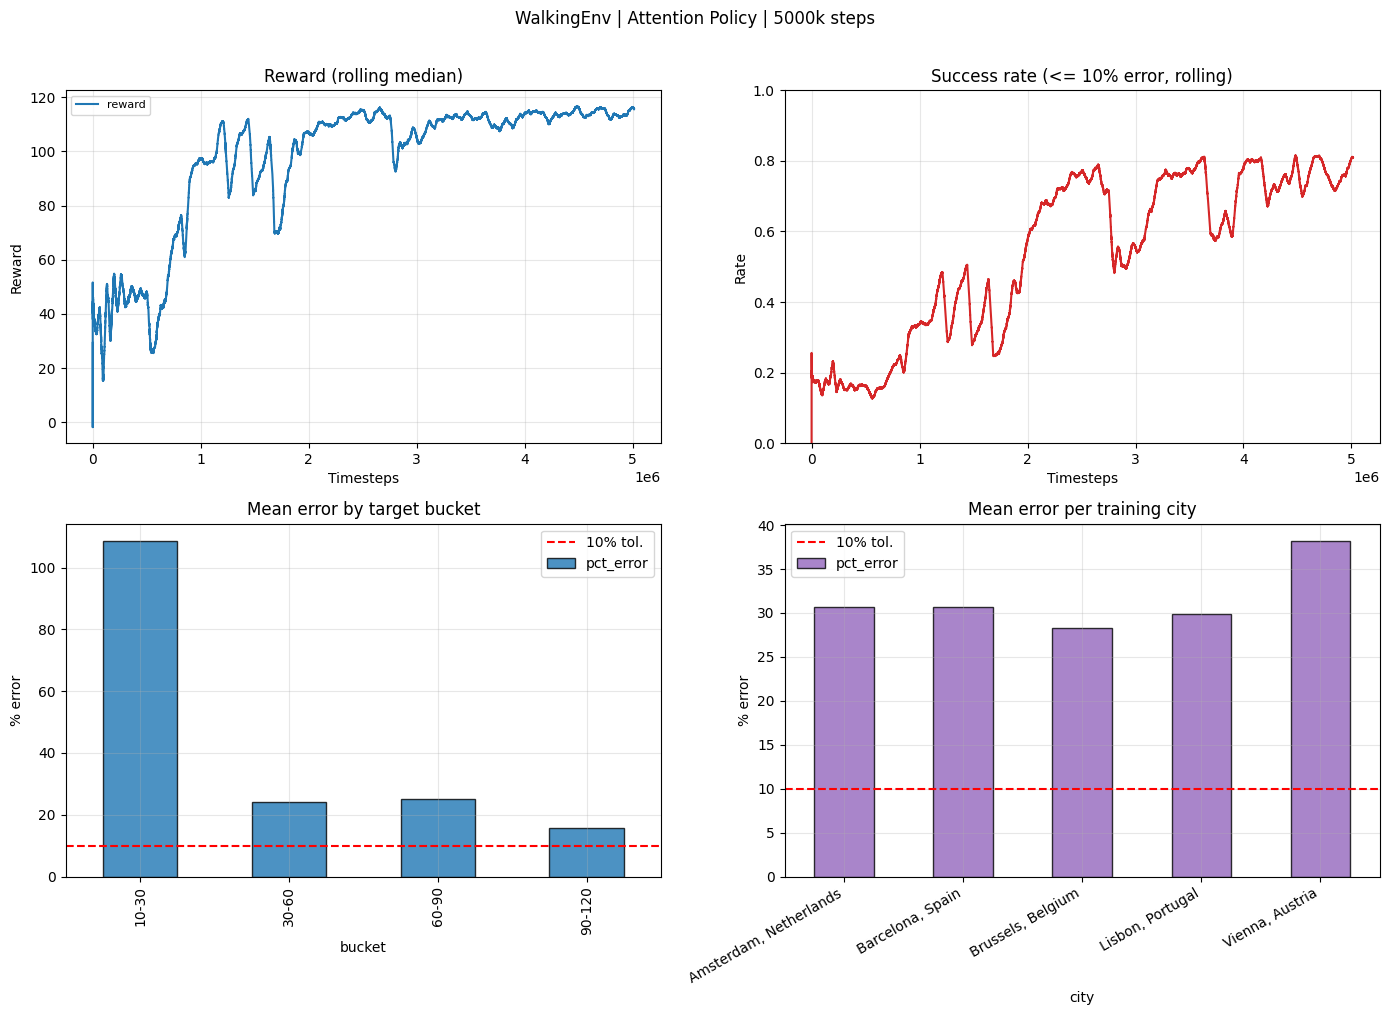

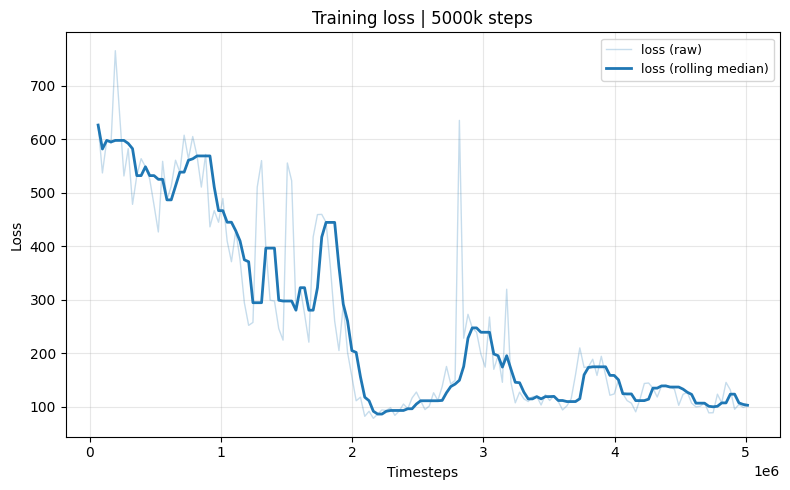

[train] final mean percentage error: 2.98%


In [ ]:
def _setup_cuda():      # Enable CUDA optimizations and mixed precision for faster training on compatible GPUs
    if not torch.cuda.is_available():
        print("[cuda] no GPU — running on CPU")
        return
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    print(f"[cuda] {torch.cuda.get_device_properties(0).name} — TF32 enabled")


def _make_env(places, cfg):
    return Monitor(WalkingEnv(places=places, cfg=cfg))


def _preload_cities(places, cfg):
    # Load/download every graph once in the main process; workers then hit cache.
    tmp = WalkingEnv(places=list(dict.fromkeys(places)), cfg=cfg)
    tmp.close()


def make_vec_env(places, cfg, n_envs):
    env_fn = partial(_make_env, places=places, cfg=cfg)
    return SubprocVecEnv([env_fn for _ in range(n_envs)], start_method="fork")


class CurriculumCallback(BaseCallback): # Widens the target duration range in three phases: [60,120] → [30,120] → [10,120].

    def __init__(self, cfg, verbose=0):
        super().__init__(verbose)
        self._cfg = cfg
        self._phase = 1

    def _on_step(self):
        t, tc = self.num_timesteps, self._cfg.train
        if self._phase == 1 and t >= tc.curriculum_phase2_start:
            self._phase = 2
            self.training_env.env_method("set_target_range", 30.0, 120.0)
        elif self._phase == 2 and t >= tc.curriculum_phase3_start:
            self._phase = 3
            self.training_env.env_method(
                "set_target_range", self._cfg.env.final_min_target, self._cfg.env.final_max_target
            )
        return True


class RewardLoggerCallback(BaseCallback): # Per-episode records for the learning-curve plots

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.records = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" not in info:
                continue
            td = info.get("target_duration", 1e-6)
            ad = info.get("current_duration", 0.0)
            self.records.append({
                "timestep": self.num_timesteps,
                "reward_total": float(info["episode"]["r"]),
                "target_duration": float(td),
                "actual_duration": float(ad),
                "pct_error": abs(td - ad) / max(td, 1e-6),
                "city": info.get("current_city", ""),
            })
        return True


class LossLoggerCallback(BaseCallback): # Captures PPO loss after each update for plotting the training curve of the loss function

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.records = []

    def _capture(self):
        vals = self.model.logger.name_to_value
        if "train/loss" not in vals:
            return
        rec = {"timestep": self.num_timesteps, "loss": float(vals["train/loss"])}
        if not self.records or self.records[-1]["timestep"] != rec["timestep"]:
            self.records.append(rec)

    def _on_step(self):
        return True

    def _on_rollout_end(self):
        self._capture()

    def _on_training_end(self):
        self._capture()


def _quick_eval(model, env, n_episodes=50):   # Quick evaluation loop to estimate the mean percentage error of the model on a set of episodes, used for tracking progress during training and for ablations, not a full evaluation on the test set.
    errors = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            masks = env.action_masks()
            action, _ = model.predict(obs[np.newaxis], action_masks=masks[np.newaxis], deterministic=True)
            obs, _, terminated, truncated, info = env.step(int(action[0]))
            done = terminated or truncated
        td = info.get("target_duration", 1e-6)
        ad = info.get("current_duration", 0.0)
        errors.append(abs(td - ad) / max(td, 1e-6))
    return float(np.mean(errors)) if errors else 1.0


def _save_learning_curves(records, cfg): 
    os.makedirs("episode_plots", exist_ok=True)
    df = pd.DataFrame(records)
    window = max(50, len(df) // 100)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(df["timestep"], df["reward_total"].rolling(window, min_periods=1).median(),
            color="C0", linewidth=1.5, label="reward")
    ax.set_title("Reward (rolling median)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Reward")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[0, 1]
    df["success"] = (df["pct_error"] <= 0.10).astype(float)
    ax.plot(df["timestep"], df["success"].rolling(window, min_periods=1).mean(), color="C3", linewidth=1.5)
    ax.set_title("Success rate (<= 10% error, rolling)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    bucket_order = ["10-30", "30-60", "60-90", "90-120"]
    df["bucket"] = df["target_duration"].apply(_bucket)
    grouped = (df.groupby("bucket")["pct_error"].mean() * 100).reindex(bucket_order)
    grouped.plot.bar(ax=ax, color="C0", edgecolor="black", alpha=0.8)
    ax.axhline(10, color="r", linestyle="--", label="10% tol.")
    ax.set_title("Mean error by target bucket")
    ax.set_ylabel("% error")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    (df.groupby("city")["pct_error"].mean() * 100).plot.bar(ax=ax, color="C4", edgecolor="black", alpha=0.8)
    ax.axhline(10, color="r", linestyle="--", label="10% tol.")
    ax.set_title("Mean error per training city")
    ax.set_ylabel("% error")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    plt.suptitle(f"WalkingEnv | Attention Policy | {cfg.train.total_timesteps // 1_000}k steps", y=1.01)
    plt.tight_layout()
    plt.savefig("episode_plots/learning_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def _save_loss_curve(records, cfg):
    os.makedirs("episode_plots", exist_ok=True)
    df = pd.DataFrame(records)
    window = max(5, len(df) // 50)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["timestep"], df["loss"], color="C0", alpha=0.25, linewidth=1, label="loss (raw)")
    ax.plot(df["timestep"], df["loss"].rolling(window, min_periods=1).median(),
            color="C0", linewidth=2, label="loss (rolling median)")
    ax.set_title(f"Training loss | {cfg.train.total_timesteps // 1_000}k steps")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("episode_plots/loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def train(cfg=CONFIG): # Main training function
    tc = cfg.train
    _setup_cuda()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[train] device={device}  steps={tc.total_timesteps:,}  n_envs={tc.n_envs}")

    all_places = list(dict.fromkeys(list(tc.training_cities) + list(tc.eval_cities)))
    _preload_cities(all_places, cfg.env)

    vec_env = make_vec_env(list(tc.training_cities), cfg.env, tc.n_envs)
    eval_env = WalkingEnv(places=list(tc.eval_cities), cfg=cfg.env)
    vec_env.env_method("set_target_range", cfg.env.initial_min_target, cfg.env.initial_max_target)

    is_cuda = torch.cuda.is_available()
    policy_kwargs = dict(   # addictional keyword arguments for the policy
        num_pois=cfg.env.num_pois, policy_cfg=cfg.policy,
        use_amp=is_cuda, compile_encoder=is_cuda,
    )
    model = MaskablePPO(    
        WalkingAttentionPolicy, vec_env, verbose=0,
        learning_rate=tc.learning_rate, n_steps=tc.n_steps, batch_size=tc.batch_size,
        n_epochs=tc.n_epochs, gamma=tc.gamma, gae_lambda=tc.gae_lambda,
        ent_coef=tc.ent_coef, clip_range=tc.clip_range, vf_coef=tc.vf_coef,
        policy_kwargs=policy_kwargs, device=device
    )
    print(f"[train] policy parameters: {sum(p.numel() for p in model.policy.parameters()):,}")

    reward_logger = RewardLoggerCallback()
    loss_logger = LossLoggerCallback()
    curriculum = CurriculumCallback(cfg)

    t0 = time.time()
    model.learn(total_timesteps=tc.total_timesteps,
                callback=[reward_logger, loss_logger, curriculum], progress_bar=True)
    print(f"[train] done in {(time.time() - t0) / 3600:.2f} h")

    model.save(tc.model_save_path)
    mean_error = _quick_eval(model, eval_env, n_episodes=50)
    print(f"[train] model -> {tc.model_save_path}.zip | final mean_pct_error = {mean_error*100:.2f}%")

    vec_env.close()
    eval_env.close()

    if reward_logger.records:
        _save_learning_curves(reward_logger.records, cfg)
    if loss_logger.records:
        _save_loss_curve(loss_logger.records, cfg)
    return mean_error

mean_err = train(CONFIG)
print(f"[train] final mean percentage error: {mean_err * 100:.2f}%")

### Evaluation

Zero-shot evaluation on held-out cities.  
It produces the summary tables, the hero plot and best/worst route maps.

Loading cached graph for Florence, Italy …
Loading cached graph for Prague, Czech Republic …
Loading cached graph for Copenhagen, Denmark …
Loading cached graph for Bruges, Belgium …
Loading cached graph for Rome, Italy …


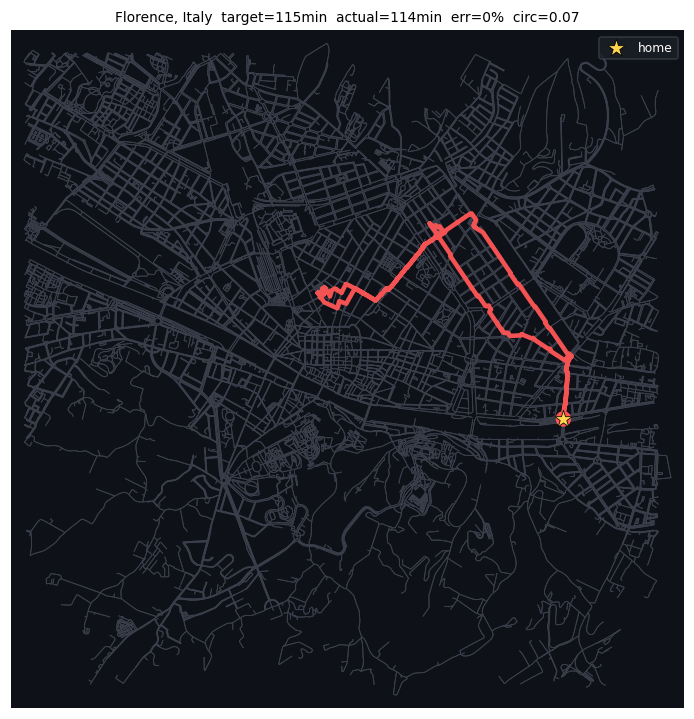

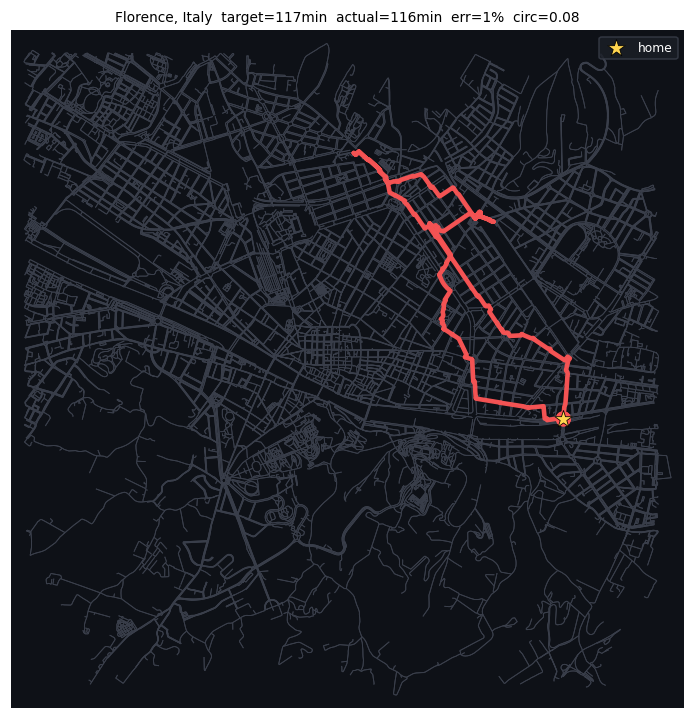

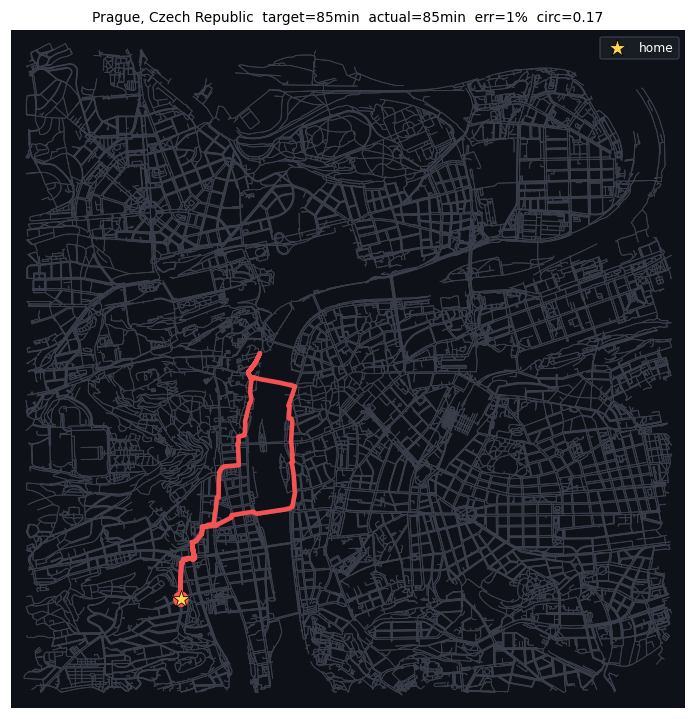

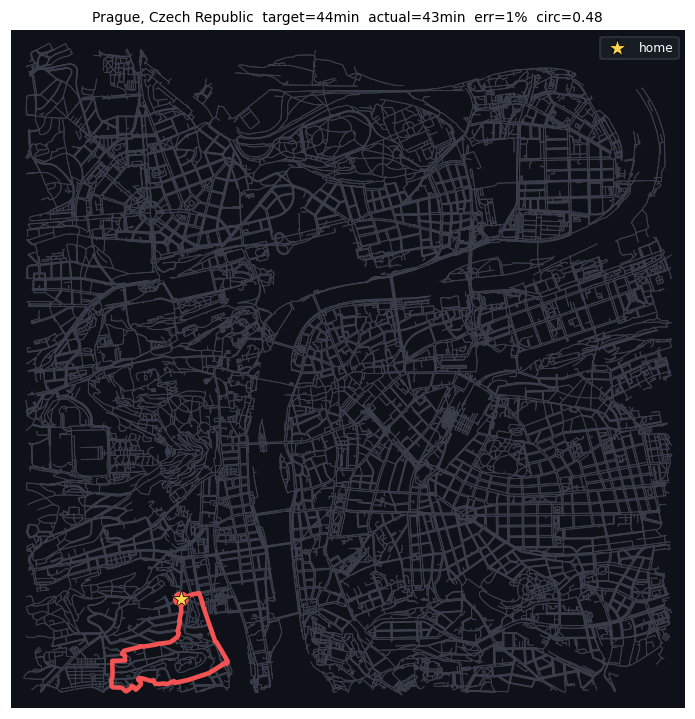

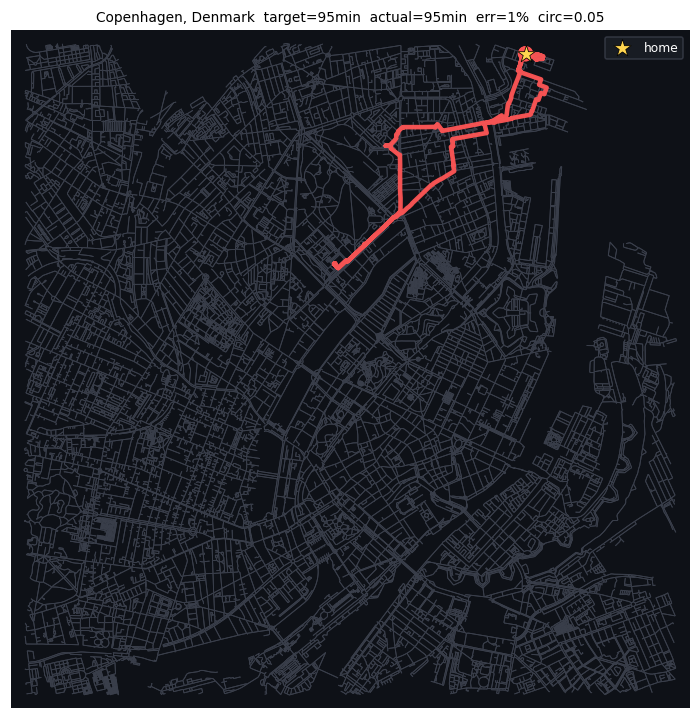

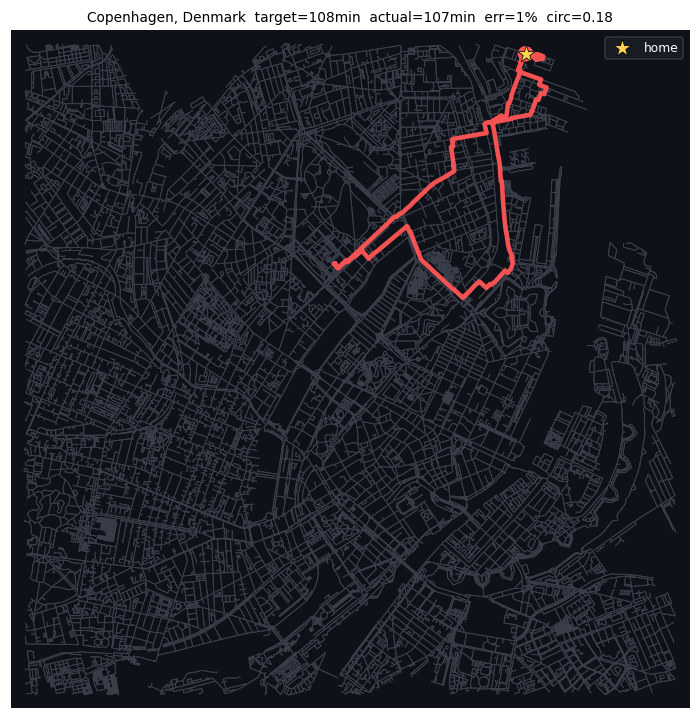

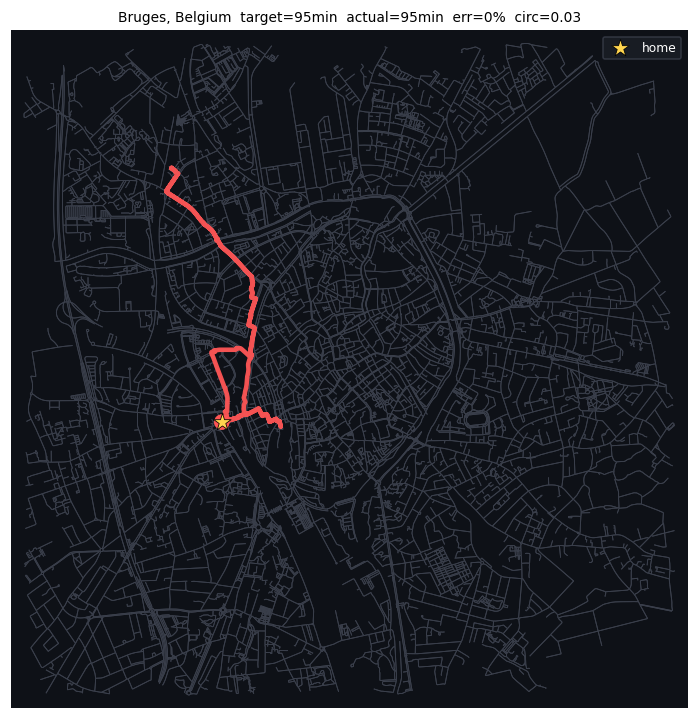

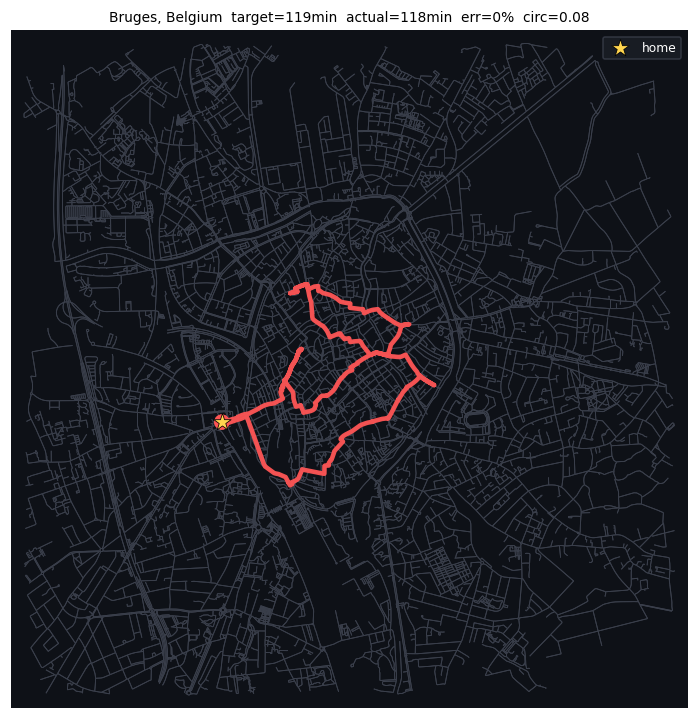

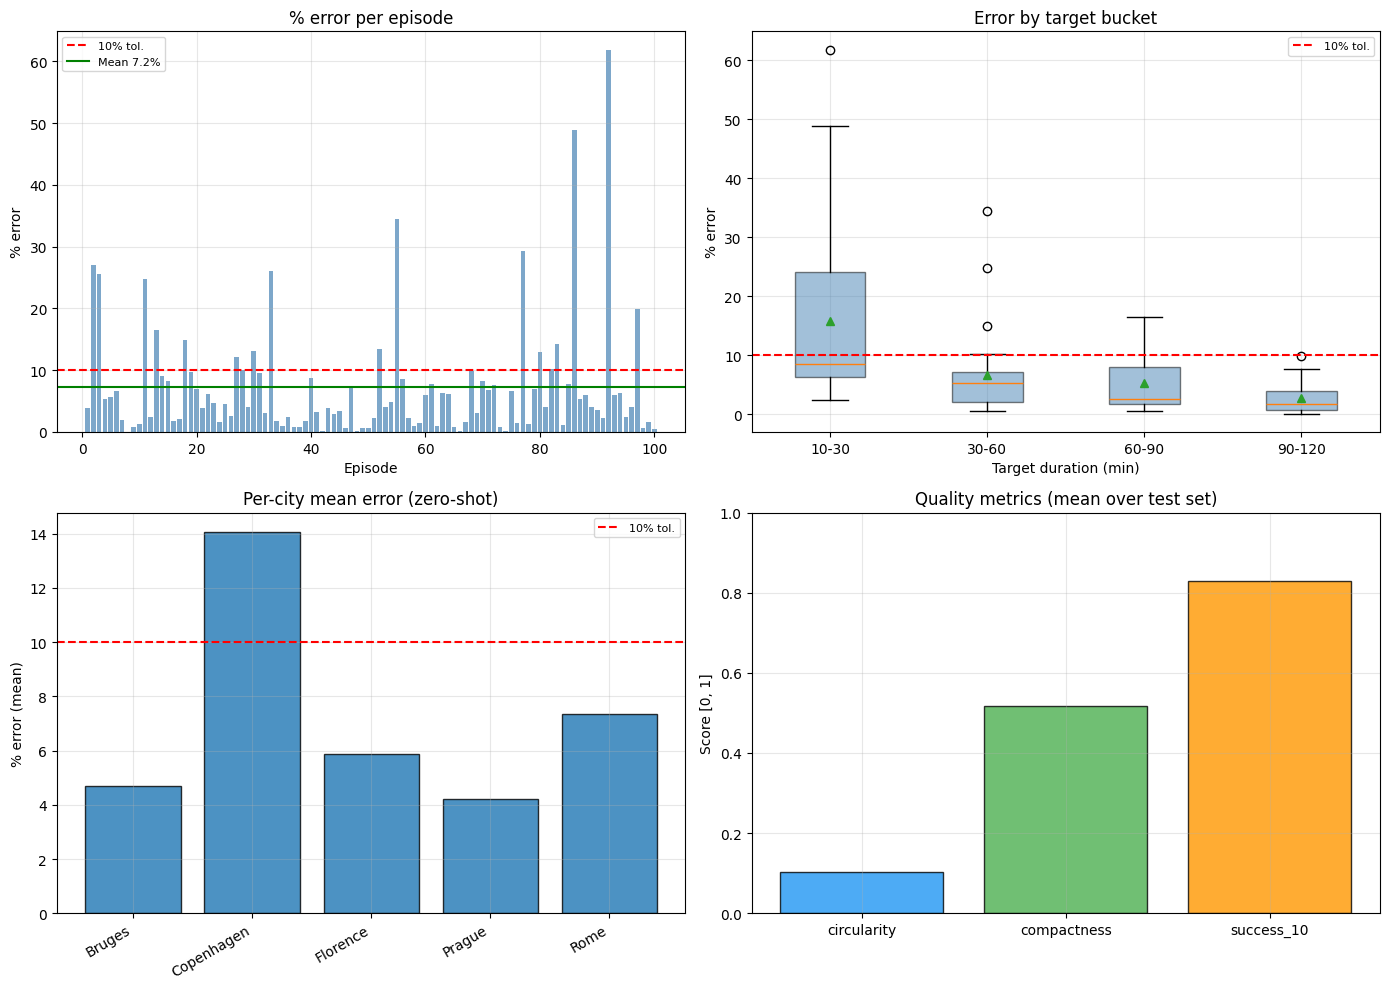

Episodes        : 100
Mean % error    : 7.24%
Median % error  : 4.09%
Sucess <=10%   : 83.0%
Mean circularity: 0.102
Mean edge-revis.: 0.265
Per-city evaluation results:


,mean_err,success_10,n
city,,,
"Bruges, Belgium",4.691273,0.95,20
"Copenhagen, Denmark",14.078053,0.55,20
"Florence, Italy",5.888436,0.90,20
"Prague, Czech Republic",4.198079,1.00,20
"Rome, Italy",7.355846,0.75,20



Overall evaluation summary by target duration bucket and city:


,city,target_bucket,pct_error_mean,success_rate_10,circularity_mean,n
0,"Bruges, Belgium",10-30,12.392218,0.800000,0.027084,5
1,"Bruges, Belgium",30-60,2.198609,1.000000,0.074690,6
2,"Bruges, Belgium",60-90,1.240008,1.000000,0.149666,2
3,"Bruges, Belgium",90-120,2.313243,1.000000,0.076228,7
4,"Copenhagen, Denmark",10-30,32.123237,0.250000,0.000000,4
5,"Copenhagen, Denmark",30-60,17.606631,0.400000,0.046202,5
6,"Copenhagen, Denmark",60-90,10.336524,0.400000,0.070146,5
7,"Copenhagen, Denmark",90-120,2.225390,1.000000,0.116267,6
8,"Florence, Italy",10-30,12.161133,0.750000,0.069482,4
9,"Florence, Italy",30-60,6.582981,0.857143,0.100318,7



Worst 10 episodes by % error:


,city,target_duration,actual_duration,pct_error,circularity
91,"Copenhagen, Denmark",13.782737,22.298659,0.617869,0.000000
85,"Copenhagen, Denmark",14.975002,22.298659,0.489059,0.000000
54,"Copenhagen, Denmark",45.786336,61.561403,0.344537,0.034651
76,"Bruges, Belgium",18.144912,23.457730,0.292799,0.001672
1,"Florence, Italy",16.389197,20.827609,0.270813,0.171484
32,"Rome, Italy",21.868057,27.575187,0.260980,0.213395
2,"Rome, Italy",23.155367,29.072082,0.255522,0.077844
10,"Copenhagen, Denmark",44.288218,55.255581,0.247636,0.104998
96,"Rome, Italy",12.796104,15.348312,0.199452,0.188788
12,"Rome, Italy",61.943642,72.179658,0.165247,0.018118


In [10]:
TEST_CITIES = [
    "Florence, Italy", "Prague, Czech Republic", "Copenhagen, Denmark",
    "Bruges, Belgium", "Rome, Italy",
]

SEED = 42
N_PER_CITY = 20
OUTPUT_DIR = "test_plots"
MODEL_PATH = "ppo_walking"


def _run_episode(model, env, case, seed=None): # Run a single episod with the given model and environment, using the specifeid target duration and city from the case, and computethe metrics for the episode path.
    obs, _ = env.reset(seed=seed, options={"target_duration": case["target_duration"], "city": case["city"]})
    done = False
    while not done:
        masks = env.action_masks()
        action, _ = model.predict(obs[np.newaxis], action_masks=masks[np.newaxis], deterministic=True)
        obs, _, terminated, truncated, info = env.step(int(action[0]))
        done = terminated or truncated
    m = compute_loop_metrics(env.G, info["episode_path"], case["target_duration"],
                             info["current_duration"], episode_pois=env.episode_pois)
    m["city"] = info["current_city"]
    m["episode_path"] = info["episode_path"]
    return m


def _save_route_plot(env, path_nodes, row, out_path):   # Save a plot of the episode path on the city graph, with annotations for the target and actual durations and all the other metrics
    fig, ax = ox.plot_graph_route(
        env.G, path_nodes, route_color="#ff5555", route_linewidth=3, route_alpha=0.95,
        node_size=0, bgcolor="#0e1117", edge_color="#3a3f4b", edge_linewidth=0.6,
        show=False, close=False,
    )
    fig.patch.set_facecolor("#0e1117")
    hx, hy = env.G.nodes[env.home_node]["x"], env.G.nodes[env.home_node]["y"]
    ax.scatter([hx], [hy], c="#ffd54f", s=140, marker="*", zorder=5,
               edgecolors="black", linewidths=0.5, label="home")
    ax.set_title(
        f"{row['city']}  target={row['target_duration']:.0f}min  "
        f"actual={row['actual_duration']:.0f}min  err={row['pct_error']*100:.0f}%  "
        f"circ={row['circularity']:.2f}",
        fontsize=9, color="black",
    )
    leg = ax.legend(loc="upper right", fontsize=8, facecolor="#1b1f27", edgecolor="#3a3f4b")
    for txt in leg.get_texts():
        txt.set_color("white")
    fig.savefig(out_path, dpi=110, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)


def _save_best_worst_routes(env, df, output_dir, k=3): # it saves plots of the best and wost k (=3) routes
    routes_dir = os.path.join(output_dir, "routes")
    os.makedirs(routes_dir, exist_ok=True)
    for city in sorted(df["city"].unique()):
        sub = df[df["city"] == city].sort_values("pct_error")
        slug = city.split(",")[0].strip().lower().replace(" ", "_")
        for label, rows in [("best", sub.head(k)), ("worst", sub.tail(k).iloc[::-1])]:
            for _, row in rows.iterrows():
                path_nodes = row["episode_path"]
                if not isinstance(path_nodes, (list, tuple)) or len(path_nodes) <= 1:
                    continue
                env._set_active_city(city)
                _save_route_plot(env, list(path_nodes), row,
                                  os.path.join(routes_dir, f"{slug}_{label}_run{int(row['run']):03d}.png"))


def _save_hero_plot(df, output_dir): # summary plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.bar(range(1, len(df) + 1), df["pct_error"] * 100, color="steelblue", alpha=0.7)
    ax.axhline(10, color="r", linestyle="--", label="10% tol.")
    ax.axhline(df["pct_error"].mean() * 100, color="g", label=f"Mean {df['pct_error'].mean()*100:.1f}%")
    ax.set_title("% error per episode")
    ax.set_xlabel("Episode")
    ax.set_ylabel("% error")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[0, 1]
    bucket_order = ["10-30", "30-60", "60-90", "90-120"]
    data = [df[df["target_bucket"] == b]["pct_error"].values * 100 for b in bucket_order]
    bp = ax.boxplot(data, tick_labels=bucket_order, showmeans=True, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.5)
    ax.axhline(10, color="r", linestyle="--", label="10% tol.")
    ax.set_title("Error by target bucket")
    ax.set_xlabel("Target duration (min)")
    ax.set_ylabel("% error")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    city_err = df.groupby("city")["pct_error"].mean() * 100
    ax.bar(range(len(city_err)), city_err.values, color="C0", edgecolor="black", alpha=0.8)
    ax.axhline(10, color="r", linestyle="--", label="10% tol.")
    ax.set_xticks(range(len(city_err)))
    ax.set_xticklabels([c.split(",")[0] for c in city_err.index], rotation=30, ha="right")
    ax.set_title("Per-city mean error (zero-shot)")
    ax.set_ylabel("% error (mean)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    cols = ["circularity", "compactness", "success_10"]
    ax.bar(cols, df[cols].mean().values, color=["#2196F3", "#4CAF50", "#FF9800"],
           edgecolor="black", alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_title("Quality metrics (mean over test set)")
    ax.set_ylabel("Score [0, 1]")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "hero_plot.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def run_evaluation(cfg=CONFIG, model_path=MODEL_PATH, n_per_city=N_PER_CITY, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)
    env = WalkingEnv(places=TEST_CITIES, cfg=cfg.env)
    model = MaskablePPO.load(model_path)

    test_set = make_deterministic_test_set(TEST_CITIES, n_per_city, SEED)
    rows = []
    for i, case in enumerate(test_set):
        m = _run_episode(model, env, case, seed=SEED + i)
        m["run"] = i + 1
        rows.append(m)
    df = pd.DataFrame(rows)

    _save_best_worst_routes(env, df, output_dir, k=3)

    # best and worst lop for each evaluation city.
    for city in EVAL_CITIES:
        sub = df[df["city"] == city].sort_values("pct_error")
        if sub.empty:
            continue
        for label, row in [("best", sub.iloc[0]), ("worst", sub.iloc[1])]:
            env._set_active_city(city)
            tmp = os.path.join(output_dir, "routes", f"_inline_{city.split(',')[0].lower()}_{label}.png")
            _save_route_plot(env, list(row["episode_path"]), row, tmp)
            display(Image(tmp))
    env.close()

    df.drop(columns=["episode_path"]).to_csv(os.path.join(output_dir, "test_metrics.csv"), index=False)
    summary = (
        df.groupby(["city", "target_bucket"])
        .agg(pct_error_mean=("pct_error", lambda x: x.mean() * 100),
             success_rate_10=("success_10", "mean"),
             circularity_mean=("circularity", "mean"),
             n=("pct_error", "count"))
        .reset_index()
    )
    summary.to_csv(os.path.join(output_dir, "test_summary.csv"), index=False)

    _save_hero_plot(df, output_dir)

    print(f"Episodes        : {len(df)}")
    print(f"Mean % error    : {df['pct_error'].mean()*100:.2f}%")
    print(f"Median % error  : {df['pct_error'].median()*100:.2f}%")
    print(f"Sucess <=10%   : {df['success_10'].mean()*100:.1f}%")
    print(f"Mean circularity: {df['circularity'].mean():.3f}")
    print(f"Mean edge-revis.: {df['edge_revisit_ratio'].mean():.3f}")
    return df, summary


df_eval, summary_eval = run_evaluation(CONFIG, MODEL_PATH)

# Per-city summary and the worst 10 loops (tail of the error distribution).
per_city = (df_eval.groupby("city")
            .agg(mean_err=("pct_error", lambda x: x.mean() * 100),
                 success_10=("success_10", "mean"),
                 n=("pct_error", "count")))
print("Per-city evaluation results:")
display(per_city)

print("\nOverall evaluation summary by target duration bucket and city:")   
display(summary_eval)

print("\nWorst 10 episodes by % error:")
display(df_eval.nlargest(10, "pct_error")[
    ["city", "target_duration", "actual_duration", "pct_error", "circularity"]
])

### RLHF Fine-Tune

Learn the user's qualitative preference from 1–10 ratings in order to fine-tune the model and achieve better visible results

In [ ]:
RATINGS_FILE = "rlhf_feedback/ratings.jsonl"
RM_PATH = "rlhf_feedback/reward_model.npz"
RLHF_MODEL_PATH = "ppo_walking_rlhf"

FEATURE_NAMES = (
    "circularity", "compactness", "edge_revisit_ratio", "node_revisit_ratio",
    "mean_turning_angle_rad", "poi_count", "pct_error",
)


def features_from_metrics(m):
    return np.array([float(m.get(n, 0.0)) for n in FEATURE_NAMES], dtype=np.float64)


class RidgeRewardModel: # Linear rating = b + wTransposed * standardise(features). Closed-form ridge.

    def __init__(self, alpha=1.0):
        self.alpha = float(alpha)
        self.mean = self.std = self.w = None
        self.b = 5.5

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self.mean, self.std = X.mean(0), X.std(0)
        self.std[self.std < 1e-8] = 1.0
        Xs = (X - self.mean) / self.std
        self.b = float(y.mean())
        A = Xs.T @ Xs + self.alpha * np.eye(Xs.shape[1])
        self.w = np.linalg.solve(A, Xs.T @ (y - self.b))

    def predict_one(self, feats):
        if self.w is None:
            return self.b
        return float(np.clip(((feats - self.mean) / self.std) @ self.w + self.b, 1.0, 10.0))

    def importances(self):
        if self.w is None:
            return [(n, 0.0) for n in FEATURE_NAMES]
        return sorted(zip(FEATURE_NAMES, self.w.tolist()), key=lambda p: abs(p[1]), reverse=True)


def load_ratings(path):
    if not os.path.exists(path):
        return []
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


def append_ratings(path, records):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "a") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")


def generate_batch(model, env, cities, batch_size, out_dir, rng):
    os.makedirs(out_dir, exist_ok=True)
    records = []
    for i in range(batch_size):
        city = cities[i % len(cities)]
        case = {"city": city, "target_duration": float(rng.uniform(10.0, 120.0))}
        m = _run_episode(model, env, case)
        png = os.path.join(out_dir, f"loop_{i + 1:02d}.png")
        if len(m["episode_path"]) > 1:
            _save_route_plot(env, list(m["episode_path"]), m, png)
        records.append({
            "city": m["city"], "target_duration": m["target_duration"],
            "actual_duration": m["actual_duration"], "pct_error": m["pct_error"],
            "png": png, "features": features_from_metrics(m).tolist(),
        })
    return records


def collect_ratings(records): # Instruction to rate the routes: open each PNG, type a 1–10 score ('s' skip, 'q' stop)
    rated = []
    for i, r in enumerate(records):
        print(f"[{i+1}/{len(records)}] {r['city']} target={r['target_duration']:.0f} "
              f"actual={r['actual_duration']:.0f} err={r['pct_error']*100:.0f}%  -> {r['png']}")
        while True:
            ans = input("score 1-10 / s / q: ").strip().lower()
            if ans == "q":
                return rated
            if ans == "s":
                break
            try:
                score = float(ans)
            except ValueError:
                continue
            if 1.0 <= score <= 10.0:
                rated.append({**r, "rating": score})
                break
    return rated

# generate routes for human evaluation
rng = np.random.default_rng(42)

env = WalkingEnv(
    places=["Florence, Italy", "Amsterdam, Netherlands"],
    cfg=CONFIG.env
)

model = MaskablePPO.load(MODEL_PATH, device="auto")

samples = generate_batch(
    model=model,
    env=env,
    cities=["Florence, Italy", "Amsterdam, Netherlands"],
    batch_size=20,
    out_dir="rlhf_feedback/samples",
    rng=rng
)

print(f"Generated {len(samples)} routes.")

Loading cached graph for Florence, Italy …
Loading cached graph for Amsterdam, Netherlands …
Generated 20 routes.


In [29]:
# After the evaluation of the user run this cell to fine-tune the model with the collected ratings, which will train a reward model on the human feedback and then fine-tune the original PPO model using this reward model to better align with human preferences
rated = collect_ratings(samples)

append_ratings(RATINGS_FILE, rated)

print(f"Saved {len(rated)} ratings.")

class HumanRewardWrapper(gym.Wrapper): # Adds gamma * clip((rating-5.5)/4.5, -1, 1) to the terminal reward

    def __init__(self, env, reward_model, lam=10.0):
        super().__init__(env)
        self.rm = reward_model
        self.lam = float(lam)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if (terminated or truncated) and len(info.get("episode_path", [])) > 1:
            base = self.env.unwrapped
            m = compute_loop_metrics(base.G, info["episode_path"], info["target_duration"],
                                     info["current_duration"], episode_pois=base.episode_pois)
            pred = self.rm.predict_one(features_from_metrics(m))
            reward += self.lam * float(np.clip((pred - 5.5) / 4.5, -1.0, 1.0))
        return obs, reward, terminated, truncated, info


def train_reward_model(ratings, alpha=1.0, rm_path=RM_PATH): # Train the reward model using the collected ratings, standardizing the features and applying ridge regression to prevent overfitting given the small dataset, then save the model parameters to disk for later use in fine-tuning
    X = np.array([r["features"] for r in ratings], dtype=np.float64)
    y = np.array([r["rating"] for r in ratings], dtype=np.float64)
    rm = RidgeRewardModel(alpha)
    rm.fit(X, y)
    os.makedirs(os.path.dirname(rm_path) or ".", exist_ok=True)
    np.savez(rm_path, mean=rm.mean, std=rm.std, w=rm.w, b=rm.b)
    print(f"Reward model trained on {len(ratings)} ratings. What you reward:")
    for name, coef in rm.importances():
        print(f"  {name:24s} {'+' if coef >= 0 else '-'}{abs(coef):.2f}")
    return rm


def finetune(model_in, model_out, cities, env_cfg, rm, lam=10.0, steps=50_000, lr=5e-5, n_envs=4): # Fine-tune the original PPO model using the human feedback from the reward model
    def make():
        return Monitor(HumanRewardWrapper(WalkingEnv(places=cities, cfg=env_cfg), rm, lam))
    vec_env = DummyVecEnv([make for _ in range(n_envs)])
    model = MaskablePPO.load(model_in, env=vec_env, device="auto")
    model.learning_rate = lr
    model.lr_schedule = lambda _: lr
    model.learn(total_timesteps=steps, reset_num_timesteps=False, progress_bar=True)
    model.save(model_out)
    vec_env.close()
    print(f"Fine-tuned model -> {model_out}.zip")

ratings = load_ratings(RATINGS_FILE)
print(f"{len(ratings)} ratings in {RATINGS_FILE}")
if len(ratings) >= 8:
    reward_model = train_reward_model(ratings, alpha=1.0, rm_path=RM_PATH)
    finetune(MODEL_PATH, RLHF_MODEL_PATH,
             ["Florence, Italy", "Amsterdam, Netherlands"], CONFIG.env,
             reward_model, steps=50_000)
else:
    print("Not enough ratings yet — collect at least 8 with collect_ratings().")


[1/20] Florence, Italy target=95 actual=100 err=5%  -> rlhf_feedback/samples/loop_01.png
[2/20] Amsterdam, Netherlands target=58 actual=58 err=1%  -> rlhf_feedback/samples/loop_02.png
[3/20] Florence, Italy target=104 actual=105 err=1%  -> rlhf_feedback/samples/loop_03.png
[4/20] Amsterdam, Netherlands target=87 actual=85 err=2%  -> rlhf_feedback/samples/loop_04.png
[5/20] Florence, Italy target=20 actual=21 err=1%  -> rlhf_feedback/samples/loop_05.png
[6/20] Amsterdam, Netherlands target=117 actual=114 err=3%  -> rlhf_feedback/samples/loop_06.png
[7/20] Florence, Italy target=94 actual=96 err=3%  -> rlhf_feedback/samples/loop_07.png
[8/20] Amsterdam, Netherlands target=96 actual=97 err=0%  -> rlhf_feedback/samples/loop_08.png
[9/20] Florence, Italy target=24 actual=23 err=3%  -> rlhf_feedback/samples/loop_09.png
[10/20] Amsterdam, Netherlands target=60 actual=60 err=0%  -> rlhf_feedback/samples/loop_10.png
[11/20] Florence, Italy target=51 actual=57 err=12%  -> rlhf_feedback/samples/l

Fine-tuned model -> ppo_walking_rlhf.zip


### Test

Routing Lisboa, Portugal: 100%|██████████| 81/81 [00:13<00:00,  6.04it/s]


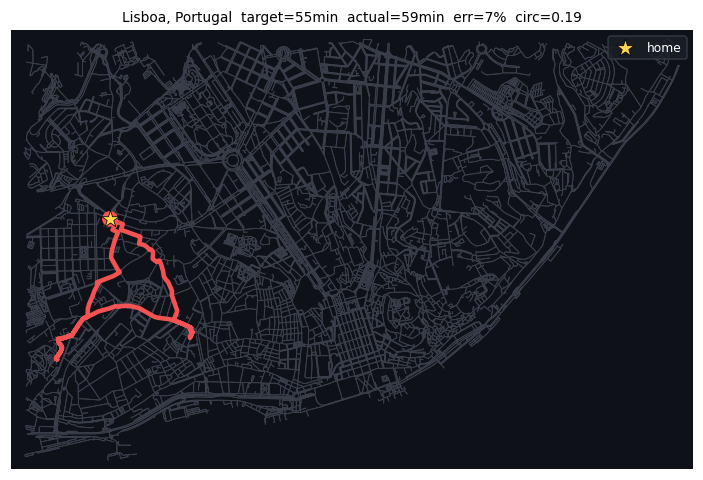

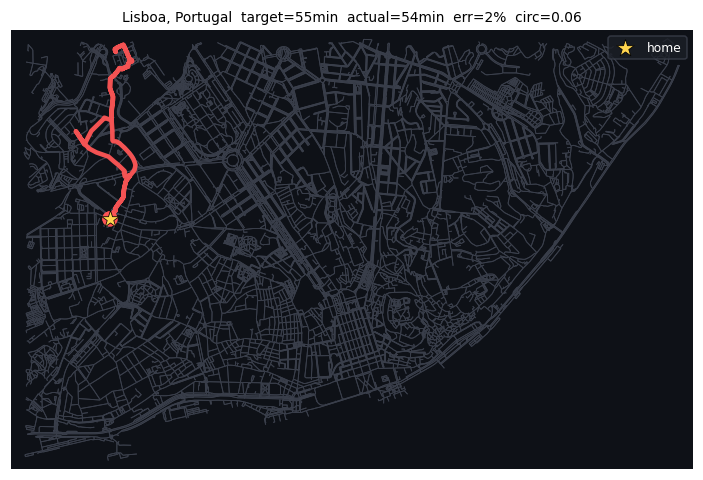

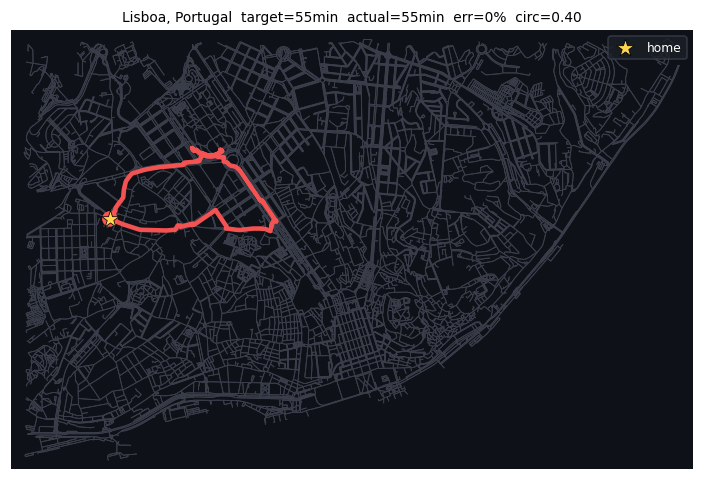

In [14]:
CITY = input("Enter a city for testing (e.g., 'Florence, Italy'): ").strip() or "Florence, Italy"
DURATION = input("Enter a target duration in minutes (e.g., 45): ").strip() or "45"
TEST_MODEL = MODEL_PATH          # use RLHF_MODEL_PATH to test the fine-tuned model

test_env = WalkingEnv(places=[CITY], cfg=CONFIG.env)
test_model = MaskablePPO.load(TEST_MODEL)

os.makedirs("test_plots/user", exist_ok=True)
for k in range(3):
    m = _run_episode(test_model, test_env, {"city": CITY, "target_duration": float(DURATION)}, seed=SEED + k)
    png = f"test_plots/user/route_{k + 1}.png"
    _save_route_plot(test_env, list(m["episode_path"]), m, png)
    display(Image(png))
test_env.close()